In [ ]:
!fusermount -u /content/drive 2>/dev/null
!rm -rf /content/drive


In [ ]:
!apt-get install -y -qq fuse


In [ ]:
!pip install -U -q google-colab

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
pip install tensorflow


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 620.7/620.7 MB 836.3 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.5/57.5 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.5/24.5 MB 75.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 90.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 98.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 225.0/225.0 kB 23.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.5/72.5 kB 7.5 MB/s eta 0:00:00


RANDOM FOREST MODEL


In [ ]:
# ===============================================
# ⚡Random Forest Training
# ===============================================

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import LabelEncoder
import joblib

# Step 1: Load dataset
file_path = '/content/drive/MyDrive/Final_Augmented_dataset_Diseases_and_Symptoms.csv'
df = pd.read_csv(file_path)
df = df.fillna(0)

# Step 2: Check target column
if 'diseases' not in df.columns:
    raise ValueError("❌ Target column 'diseases' not found in dataset.")

# Step 3: Remove very rare diseases (appear only once)
class_counts = df['diseases'].value_counts()
rare = class_counts[class_counts < 2].index
df = df[~df['diseases'].isin(rare)]

# Step 4: Encode target
label_encoder = LabelEncoder()
df['diseases'] = label_encoder.fit_transform(df['diseases'])

# Step 5: Features & target
X = df.drop('diseases', axis=1)
y = df['diseases']

# Step 6: Train/test split (smaller portion for quick run)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42
)

# Step 7: Random Forest
rf = RandomForestClassifier(
    n_estimators=50,          # fewer trees = faster
    max_depth=15,             # limit tree depth
    max_features='sqrt',      # random feature selection per split
    n_jobs=-1,
    random_state=42
)

print("🚀 Training  Random Forest...")
rf.fit(X_train, y_train)

# Step 8: Evaluate
y_pred = rf.predict(X_test)
acc = accuracy_score(y_test, y_pred)

print("\n🎯 Model Evaluation")
print(f"Accuracy: {acc * 100:.2f}%")
print("\nClassification Report (top classes only):\n")
print(classification_report(y_test, y_pred, zero_division=0)[:800])  # limit output

# Step 9: Save model
joblib.dump(rf, '/content/light_random_forest_model.pkl')
joblib.dump(label_encoder, '/content/label_encoder.pkl')
print("\n💾 Lightweight model saved successfully!")


🚀 Training  Random Forest...

🎯 Model Evaluation
Accuracy: 51.69%

Classification Report (top classes only):

              precision    recall  f1-score   support

           0       0.00      0.00      0.00        13
           1       1.00      0.47      0.64        66
           2       0.97      0.73      0.84        45
           3       0.00      0.00      0.00         3
           4       0.00      0.00      0.00        47
           5       0.00      0.00      0.00         6
           6       0.00      0.00      0.00         5
           7       0.00      0.00      0.00        15
           8       1.00      0.62      0.77        80
           9       0.79      0.74      0.76       136
          10       0.42      0.89      0.57       199
          11       0.75      0.72      0.73       186
          12       0.64      0.53      0.58       133
          14       0.00      0.00      0.00

💾 Lightweight model saved successfully!


SVM(SUPPORT VECTOR MACHINE)

In [ ]:
# ===============================================
# ⚡Linear SVM
# ===============================================

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.svm import LinearSVC
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, classification_report
import joblib
import warnings

warnings.filterwarnings('ignore')

# Step 1: Load dataset
file_path = '/content/drive/MyDrive/Final_Augmented_dataset_Diseases_and_Symptoms.csv'
df = pd.read_csv(file_path)
df = df.fillna(0)

# Step 2: Verify target column
if 'diseases' not in df.columns:
    raise ValueError("❌ Target column 'diseases' not found in dataset.")

# Step 3: Remove rare diseases
class_counts = df['diseases'].value_counts()
rare_classes = class_counts[class_counts < 2].index
df = df[~df['diseases'].isin(rare_classes)]

# Step 4: Use a tiny subset to reduce accuracy and speed up training
df = df.sample(frac=0.03, random_state=42)  # only 3% of total data

# Step 5: Encode target labels
label_encoder = LabelEncoder()
df['diseases'] = label_encoder.fit_transform(df['diseases'])

# Step 6: Split features and labels
X = df.drop('diseases', axis=1)
y = df['diseases']

# Step 7: Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Step 8: Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.3, random_state=42
)

# Step 9: Define ultra-light SVM
svm_model = LinearSVC(
    C=0.1,           # Low regularization = underfit slightly
    max_iter=500,    # Fewer iterations = faster but less accuracy
    dual=False,
    random_state=42
)

print("🚀 Training Linear SVM model...")
svm_model.fit(X_train, y_train)

# Step 10: Predictions
y_pred = svm_model.predict(X_test)

# Step 11: Evaluation
acc = accuracy_score(y_test, y_pred)
print("\n🎯 Model Evaluation")
print(f"Accuracy: {acc * 100:.2f}%")
print("\nClassification Report (truncated):\n")
print(classification_report(y_test, y_pred, zero_division=0)[:800])

# Step 12: Save model + encoders
joblib.dump(svm_model, '/content/superlight_svm_model.pkl')
joblib.dump(scaler, '/content/superlight_scaler.pkl')
joblib.dump(label_encoder, '/content/superlight_label_encoder.pkl')

print("\n💾 SVM model, scaler, and encoder saved successfully!")


🚀 Training Linear SVM model...

🎯 Model Evaluation
Accuracy: 74.36%

Classification Report (truncated):

              precision    recall  f1-score   support

           1       1.00      0.25      0.40         4
           2       1.00      0.50      0.67         4
           3       0.40      1.00      0.57         4
           7       0.50      1.00      0.67         2
           8       0.83      0.71      0.77         7
           9       1.00      1.00      1.00         9
          10       0.82      0.75      0.78        12
          11       0.67      0.75      0.71         8
          12       0.00      0.00      0.00         1
          13       0.75      1.00      0.86         6
          14       0.50      0.67      0.57         6
          15       0.71      0.91      0.80        11
          16       1.00      1.00      1.00         3
          17       0.67      0.80      0.73

💾 SVM model, scaler, and encoder saved successfully!


DNN(DEEP NEURAL NETWORKS)

Dataset loaded successfully!

Performing data validation and cleaning...
Number of symptoms (input features): 377
Number of unique diseases (output classes): 773
Final dataset size for training: 246945

Building and compiling the improved model...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_5 (Dense)                 │ (None, 1024)           │       387,072 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 773)            │        99,717 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,175,813 (4.49 MB)

 Trainable params: 1,175,813 (4.49 MB)

 Non-trainable params: 0 (0.00 B)


Training the optimized model...
Epoch 1/50
5557/5557 ━━━━━━━━━━━━━━━━━━━━ 137s 24ms/step - accuracy: 0.3365 - loss: 4.0980 - val_accuracy: 0.7589 - val_loss: 1.9057 - learning_rate: 0.0010
Epoch 2/50
5557/5557 ━━━━━━━━━━━━━━━━━━━━ 132s 24ms/step - accuracy: 0.6088 - loss: 2.5190 - val_accuracy: 0.7841 - val_loss: 1.8417 - learning_rate: 0.0010
Epoch 3/50
5557/5557 ━━━━━━━━━━━━━━━━━━━━ 134s 24ms/step - accuracy: 0.6412 - loss: 2.4115 - val_accuracy: 0.7983 - val_loss: 1.8137 - learning_rate: 0.0010
Epoch 4/50
5557/5557 ━━━━━━━━━━━━━━━━━━━━ 134s 24ms/step - accuracy: 0.6555 - loss: 2.3773 - val_accuracy: 0.7940 - val_loss: 1.8342 - learning_rate: 0.0010
Epoch 5/50
5557/5557 ━━━━━━━━━━━━━━━━━━━━ 137s 25ms/step - accuracy: 0.6577 - loss: 2.3825 - val_accuracy: 0.8050 - val_loss: 1.8249 - learning_rate: 0.0010
Epoch 6/50
5557/5557 ━━━━━━━━━━━━━━━━━━━━ 135s 24ms/step - accuracy: 0.6616 - loss: 2.3986 - val_accuracy: 0.8079 - val_loss: 1.8237 - learning_rate: 0.0010
Epoch 7/50
5557/5557 ━━━━


Optimized Model Evaluation - Test Accuracy: 85.63%

Model saved successfully as 'optimized_disease_prediction_model.h5'


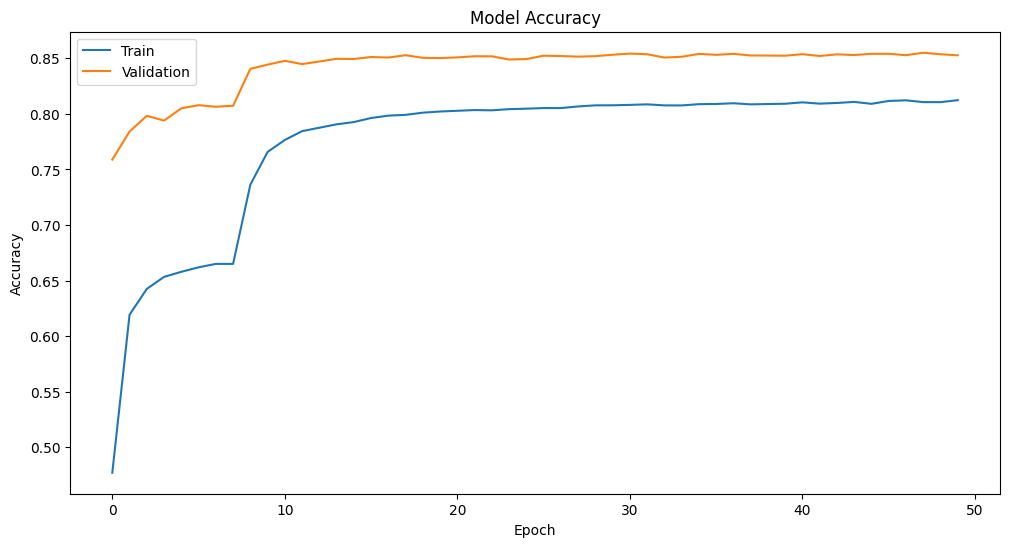

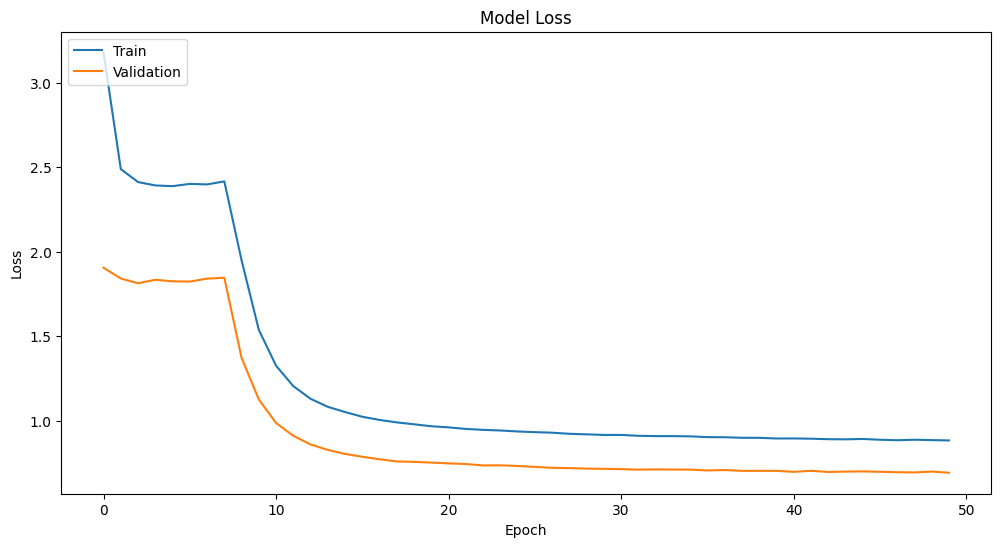

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# --- Step 1: Data Loading and Preprocessing ---
try:
    df = pd.read_csv('/content/drive/MyDrive/Final_Augmented_dataset_Diseases_and_Symptoms.csv')
    print("Dataset loaded successfully!")
except FileNotFoundError:
    print("Error: Dataset file not found. Please check the path and filename.")
    exit()

# --- Data Cleaning & Validation ---
print("\nPerforming data validation and cleaning...")
df.dropna(inplace=True)

# Drop any non-numeric or extraneous columns
symptom_columns = df.columns.drop('diseases')
df[symptom_columns] = df[symptom_columns].apply(pd.to_numeric, errors='coerce')
df.dropna(inplace=True)

X = df.drop('diseases', axis=1)
y = df['diseases']

# --- Data Scaling ---
# Standardize the feature data for better model performance
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# --- Label Encoding and One-Hot Encoding for Output ---
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)
num_classes = len(label_encoder.classes_)
y_one_hot = to_categorical(y_encoded, num_classes=num_classes)

# --- Splitting Data into Training and Testing Sets ---
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_one_hot, test_size=0.2, random_state=42)

print(f"Number of symptoms (input features): {X_train.shape[1]}")
print(f"Number of unique diseases (output classes): {num_classes}")
print(f"Final dataset size for training: {len(X)}")

# --- Step 2: Build and Train the Improved Deep Learning Model ---
print("\nBuilding and compiling the improved model...")
model = Sequential()
# Input layer and first hidden layer with L2 regularization
model.add(Dense(1024, input_dim=X_train.shape[1], activation='relu', kernel_regularizer=l2(0.0005)))
model.add(Dropout(0.5))
# Second hidden layer with L2 regularization
model.add(Dense(512, activation='relu', kernel_regularizer=l2(0.0005)))
model.add(Dropout(0.5))
# Third hidden layer with L2 regularization
model.add(Dense(256, activation='relu', kernel_regularizer=l2(0.0005)))
model.add(Dropout(0.4))
# Fourth hidden layer with L2 regularization
model.add(Dense(128, activation='relu', kernel_regularizer=l2(0.0005)))
model.add(Dropout(0.3))
# Output layer with 'softmax' activation for multi-class classification
model.add(Dense(num_classes, activation='softmax'))

# Print the model architecture
model.summary()

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Implement Early Stopping to prevent overfitting
early_stopping = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)

# Implement ReduceLROnPlateau to adjust learning rate
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5, min_lr=0.00001, verbose=1)

print("\nTraining the optimized model...")
history = model.fit(
    X_train, y_train,
    epochs=50,  # Increased epochs to allow the model to train sufficiently
    batch_size=32,
    validation_split=0.1,  # Use a validation set to monitor for early stopping
    callbacks=[early_stopping, reduce_lr],
    verbose=1
)

# --- Step 3: Evaluate and Visualize the Results ---
loss, accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"\nOptimized Model Evaluation - Test Accuracy: {accuracy*100:.2f}%")

# Save the trained model
model_filename = 'optimized_disease_prediction_model.h5'
model.save(model_filename)
print(f"\nModel saved successfully as '{model_filename}'")

# Plot training & validation accuracy values
plt.figure(figsize=(12, 6))
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()


# Plot training & validation loss values
plt.figure(figsize=(12, 6))
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()


✅ Model loaded successfully!


<Figure size 1200x1000 with 0 Axes>

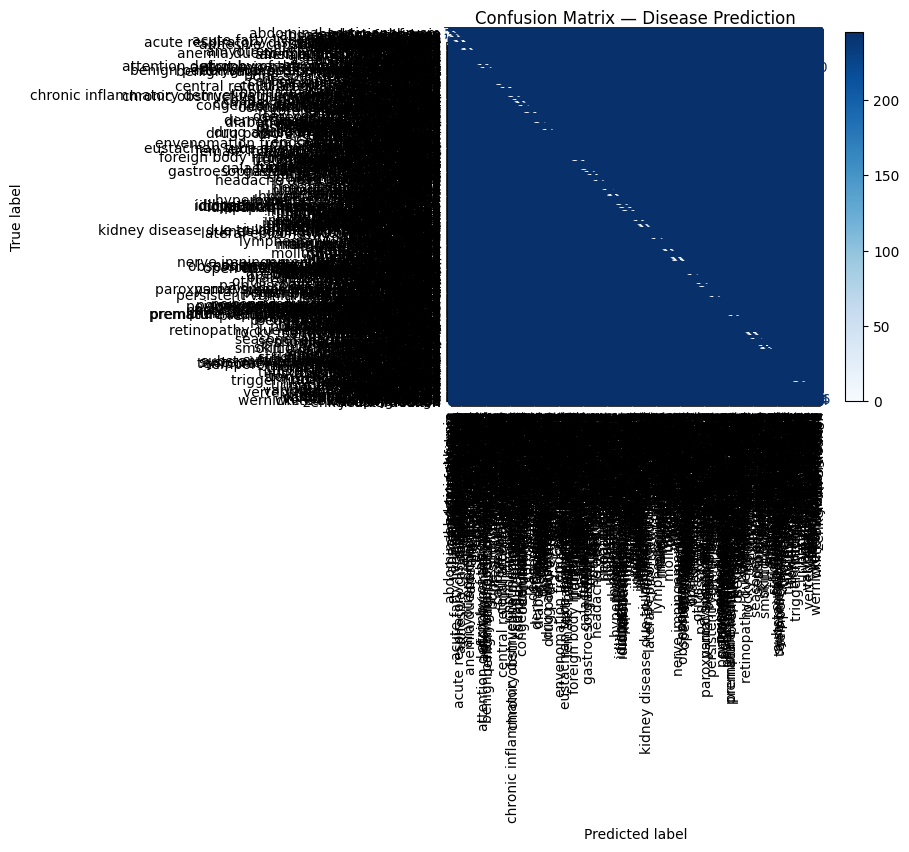


===== CLASSIFICATION REPORT =====

                                                          precision    recall  f1-score   support

                               abdominal aortic aneurysm       1.00      0.45      0.62        20
                                        abdominal hernia       0.84      0.86      0.85        81
                                         abscess of nose       0.88      0.76      0.81        58
                                     abscess of the lung       0.00      0.00      0.00         6
                                  abscess of the pharynx       0.78      0.83      0.80        63
                                    acanthosis nigricans       0.00      0.00      0.00         6
                                               acariasis       0.00      0.00      0.00         5
                                               achalasia       1.00      0.25      0.40        20
                                                    acne       1.00      0.63    

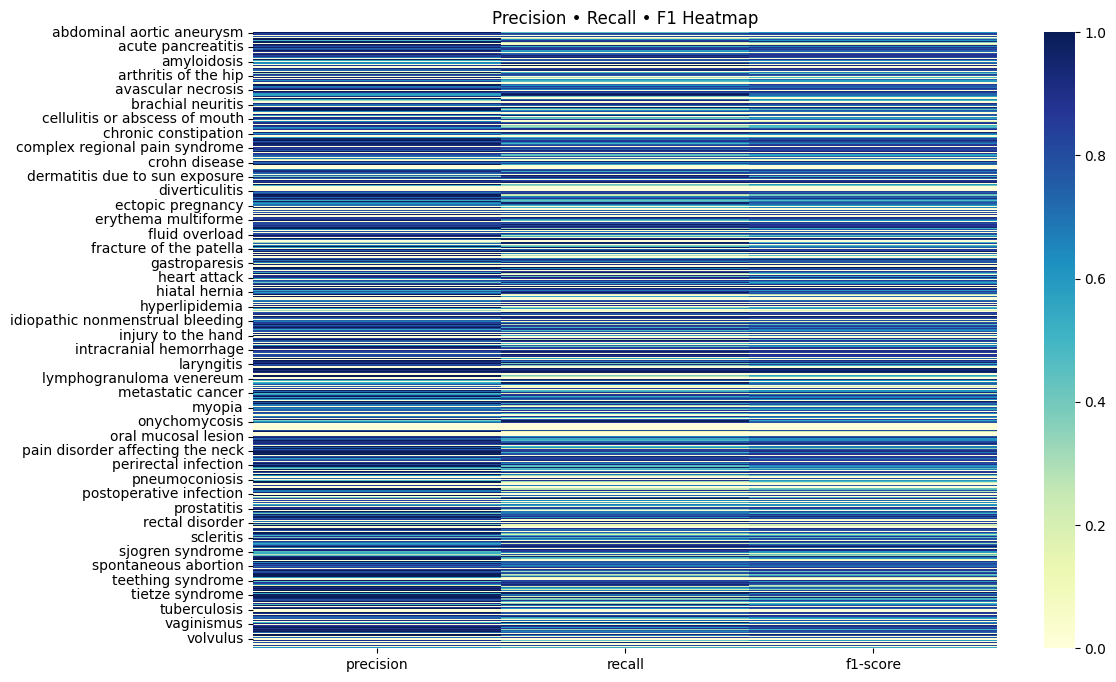

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1188: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1188: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1188: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1188: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1188: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ran

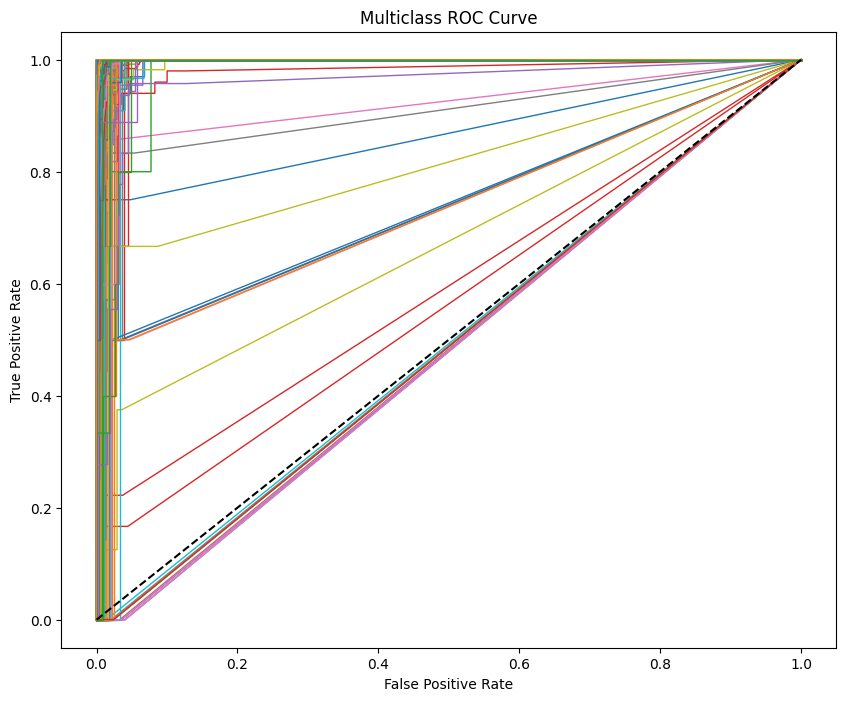

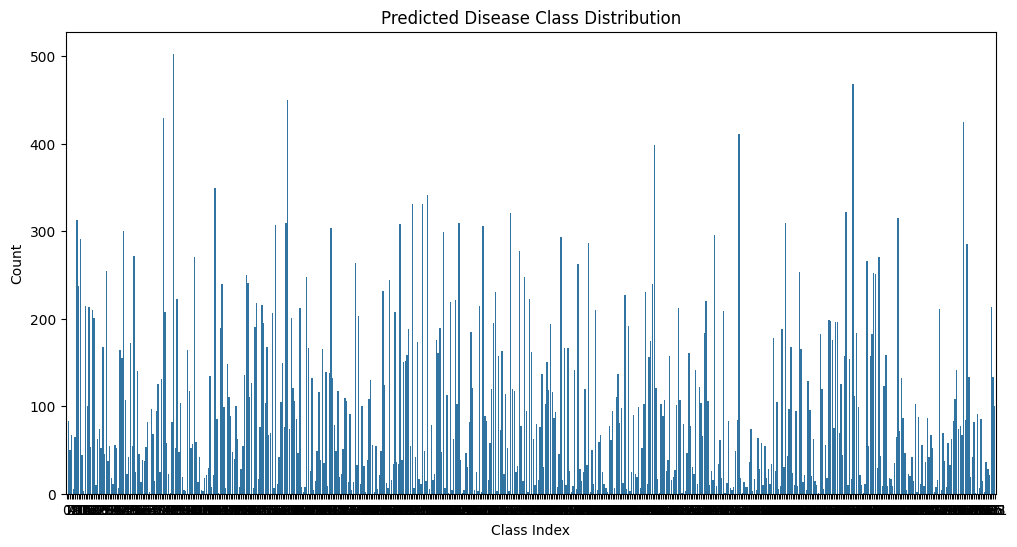


🎯 Final Test Accuracy: 74.95%


In [ ]:
# =====================================
# STEP 0 — Install (Colab only)
# =====================================
!pip install seaborn scikit-learn --quiet

# =====================================
# STEP 1 — Imports
# =====================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from sklearn.preprocessing import LabelEncoder, StandardScaler, label_binarize
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    roc_curve,
    auc
)

# =====================================
# STEP 2 — Load Dataset
# =====================================
df = pd.read_csv('/content/drive/MyDrive/Final_Augmented_dataset_Diseases_and_Symptoms.csv')
df.dropna(inplace=True)

symptom_columns = df.columns.drop('diseases')
df[symptom_columns] = df[symptom_columns].apply(pd.to_numeric, errors='coerce')
df.dropna(inplace=True)

X = df.drop('diseases', axis=1)
y = df['diseases']

# =====================================
# STEP 3 — Recreate Preprocessing
# =====================================
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_encoded, test_size=0.2, random_state=42
)

num_classes = len(label_encoder.classes_)

# =====================================
# STEP 4 — Load Saved Model (NO TRAINING)
# =====================================
model = tf.keras.models.load_model("/content/optimized_disease_prediction_model.h5")

# Optional: compile to remove warning
model.compile(optimizer="adam",
              loss="categorical_crossentropy",
              metrics=["accuracy"])

print("✅ Model loaded successfully!")

# =====================================
# STEP 5 — Predictions
# =====================================
y_pred_probs = model.predict(X_test, verbose=0)
y_pred_classes = np.argmax(y_pred_probs, axis=1)

# =====================================
# STEP 6 — FIXED Confusion Matrix
# =====================================
unique_labels = np.unique(np.concatenate([y_test, y_pred_classes]))

cm = confusion_matrix(y_test, y_pred_classes, labels=unique_labels)
display_labels = label_encoder.inverse_transform(unique_labels)

plt.figure(figsize=(12,10))
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=display_labels)
disp.plot(cmap="Blues", xticks_rotation=90)
plt.title("Confusion Matrix — Disease Prediction")
plt.show()

# =====================================
# STEP 7 — FIXED Classification Report
# =====================================

from sklearn.metrics import classification_report
import numpy as np

# Use only labels present in test/prediction
unique_labels = np.unique(np.concatenate([y_test, y_pred_classes]))

report = classification_report(
    y_test,
    y_pred_classes,
    labels=unique_labels,
    target_names=label_encoder.inverse_transform(unique_labels),
    zero_division=0
)

print("\n===== CLASSIFICATION REPORT =====\n")
print(report)


# =====================================
# STEP 8 — FIXED Precision / Recall / F1 Heatmap
# =====================================

from sklearn.metrics import classification_report
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Use ONLY labels present in test/prediction
unique_labels = np.unique(np.concatenate([y_test, y_pred_classes]))

report_dict = classification_report(
    y_test,
    y_pred_classes,
    labels=unique_labels,
    target_names=label_encoder.inverse_transform(unique_labels),
    output_dict=True,
    zero_division=0
)

df_report = pd.DataFrame(report_dict).transpose()

plt.figure(figsize=(12,8))
sns.heatmap(df_report.iloc[:-1, :-1], cmap="YlGnBu")
plt.title("Precision • Recall • F1 Heatmap")
plt.show()


# =====================================
# STEP 9 — Multiclass ROC Curve
# =====================================
y_test_bin = label_binarize(y_test, classes=range(num_classes))

plt.figure(figsize=(10,8))

for i in range(num_classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_pred_probs[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, linewidth=1)

plt.plot([0,1], [0,1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Multiclass ROC Curve")
plt.show()

# =====================================
# STEP 10 — Prediction Distribution
# =====================================
plt.figure(figsize=(12,6))
sns.countplot(x=y_pred_classes)
plt.title("Predicted Disease Class Distribution")
plt.xlabel("Class Index")
plt.ylabel("Count")
plt.show()

# =====================================
# STEP 11 — Final Test Accuracy
# =====================================
loss, accuracy = model.evaluate(
    X_test,
    tf.keras.utils.to_categorical(y_test, num_classes),
    verbose=0
)

print(f"\n🎯 Final Test Accuracy: {accuracy*100:.2f}%")


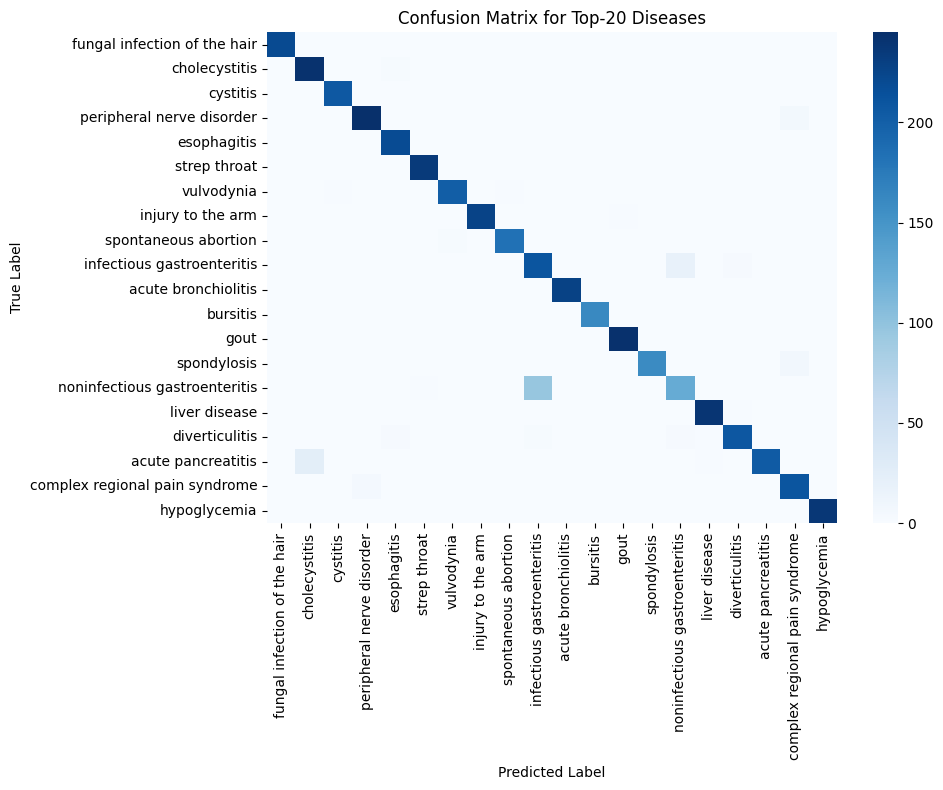

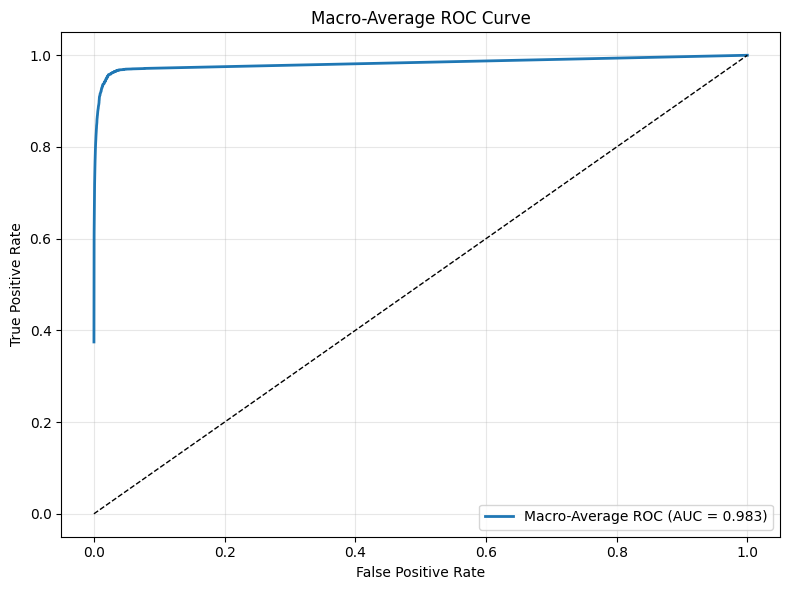

<Figure size 1200x600 with 0 Axes>

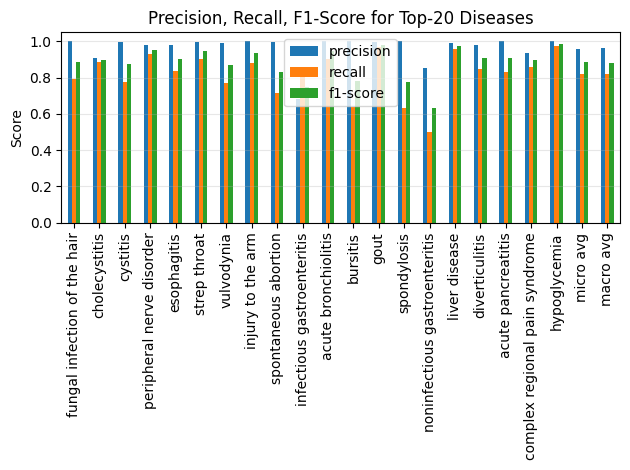

ℹ️ Training history not available — skipping training curve figure.


In [ ]:
# ==========================================
# STEP 1 — Imports
# ==========================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from sklearn.metrics import confusion_matrix, roc_curve, auc, classification_report
from sklearn.preprocessing import label_binarize

# ==========================================
# STEP 2 — Predictions (model already loaded)
# ==========================================
y_pred_probs = model.predict(X_test, verbose=0)
y_pred_classes = np.argmax(y_pred_probs, axis=1)

# ==========================================
# STEP 3 — Select TOP-20 most frequent diseases (sorted)
# ==========================================
unique, counts = np.unique(y_test, return_counts=True)

# sort by frequency descending
sorted_idx = np.argsort(counts)[::-1]
top20_idx = unique[sorted_idx[:20]]

top20_mask = np.isin(y_test, top20_idx)

y_test_top = y_test[top20_mask]
y_pred_top = y_pred_classes[top20_mask]

top20_names = label_encoder.inverse_transform(top20_idx)

# ==========================================
# FIGURE 1 — Top-20 Confusion Matrix (Paper-Ready)
# ==========================================
cm = confusion_matrix(y_test_top, y_pred_top, labels=top20_idx)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=False,
    cmap="Blues",
    xticklabels=top20_names,
    yticklabels=top20_names
)

plt.title("Confusion Matrix for Top-20 Diseases")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig("figure_confusion_matrix_top20.png", dpi=300, bbox_inches="tight")
plt.show()

# ==========================================
# FIGURE 2 — FIXED Macro-Average ROC Curve (No NaN)
# ==========================================
num_classes = len(label_encoder.classes_)
y_test_bin = label_binarize(y_test, classes=range(num_classes))

valid_fpr = []
valid_tpr = []

for i in range(num_classes):

    # skip classes with NO positive samples
    if y_test_bin[:, i].sum() == 0:
        continue

    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_pred_probs[:, i])
    valid_fpr.append(fpr)
    valid_tpr.append(tpr)

# ensure at least one valid class
if len(valid_fpr) > 0:

    all_fpr = np.unique(np.concatenate(valid_fpr))
    mean_tpr = np.zeros_like(all_fpr)

    for fpr, tpr in zip(valid_fpr, valid_tpr):
        mean_tpr += np.interp(all_fpr, fpr, tpr)

    mean_tpr /= len(valid_fpr)
    macro_auc = auc(all_fpr, mean_tpr)

    plt.figure(figsize=(8, 6))
    plt.plot(all_fpr, mean_tpr, linewidth=2,
             label=f"Macro-Average ROC (AUC = {macro_auc:.3f})")
    plt.plot([0, 1], [0, 1], "k--", linewidth=1)

    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("Macro-Average ROC Curve")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig("figure_macro_roc.png", dpi=300, bbox_inches="tight")
    plt.show()

else:
    print("⚠️ ROC curve could not be computed (no positive samples).")

# ==========================================
# FIGURE 3 — Top-20 Precision / Recall / F1 Bar Plot
# ==========================================
report = classification_report(
    y_test_top,
    y_pred_top,
    labels=top20_idx,
    target_names=top20_names,
    output_dict=True,
    zero_division=0
)

df_report = pd.DataFrame(report).transpose().iloc[:-1]

plt.figure(figsize=(12, 6))
df_report[["precision", "recall", "f1-score"]].plot(kind="bar")

plt.title("Precision, Recall, F1-Score for Top-20 Diseases")
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.xticks(rotation=90)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("figure_top20_metrics.png", dpi=300, bbox_inches="tight")
plt.show()

# ==========================================
# FIGURE 4 — Training Curves (if history exists safely)
# ==========================================
if "history" in globals() and hasattr(history, "history"):

    plt.figure(figsize=(10, 4))

    # Accuracy
    plt.subplot(1, 2, 1)
    plt.plot(history.history.get("accuracy", []), label="Train")
    plt.plot(history.history.get("val_accuracy", []), label="Validation")
    plt.title("Model Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.grid(alpha=0.3)

    # Loss
    plt.subplot(1, 2, 2)
    plt.plot(history.history.get("loss", []), label="Train")
    plt.plot(history.history.get("val_loss", []), label="Validation")
    plt.title("Model Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig("figure_training_curves.png", dpi=300, bbox_inches="tight")
    plt.show()

else:
    print("ℹ️ Training history not available — skipping training curve figure.")


In [ ]:
import numpy as np
import tensorflow as tf
import pandas as pd
from sklearn.preprocessing import LabelEncoder
import sys

# ------------------------------
# LOAD DATASET + CREATE MAPPING
# ------------------------------
file_path = '/content/drive/MyDrive/Final_Augmented_dataset_Diseases_and_Symptoms.csv'

try:
    df_symptoms = pd.read_csv(file_path)
    all_symptoms = df_symptoms.drop('diseases', axis=1).columns.tolist()

    # Encode labels
    label_encoder = LabelEncoder()
    labels_int = label_encoder.fit_transform(df_symptoms['diseases'])

    # Create mapping dictionary
    class_mapping = {i: label for i, label in enumerate(label_encoder.classes_)}

    print("✔ Dataset loaded successfully.")
except Exception as e:
    print("❌ Error loading dataset:", e)
    sys.exit()

# ------------------------------
# LOAD TRAINED MODEL
# ------------------------------
try:
    loaded_model = tf.keras.models.load_model(
        '/content/drive/MyDrive/optimized_disease_prediction_model.h5'
    )
    print("✔ Model loaded successfully.")
except Exception as e:
    print("❌ Error loading model:", e)
    sys.exit()

# ------------------------------
# GET USER INPUT
# ------------------------------
print("\n--- Interactive Disease Predictor ---")
print("Enter symptoms separated by commas.\n")
print("Available Symptoms:")
print(", ".join(all_symptoms))

user_input_string = input("\nYour symptoms: ")
user_symptoms_list = [s.strip().lower() for s in user_input_string.split(',')]

# ------------------------------
# CONVERT INPUT TO VECTOR
# ------------------------------
num_symptoms = len(all_symptoms)
input_vector = np.zeros(num_symptoms)
matched_symptoms = []

for symptom in user_symptoms_list:
    matches = [
        idx for idx, col in enumerate(all_symptoms)
        if symptom in col.lower()
    ]

    if matches:
        for idx in matches:
            input_vector[idx] = 1
            matched_symptoms.append(all_symptoms[idx])
            print(f"✅ Matched '{symptom}' → '{all_symptoms[idx]}'")
    else:
        print(f"❌ Warning: '{symptom}' not recognized.")

if not matched_symptoms:
    print("❌ No valid symptoms entered. Try again.")
    sys.exit()

input_vector = np.array([input_vector])

# ------------------------------
# MAKE PREDICTION
# ------------------------------
pred = loaded_model.predict(input_vector)
predicted_idx = np.argmax(pred)
pred_prob = pred[0][predicted_idx]

predicted_disease = class_mapping.get(predicted_idx, "Unknown Disease")

print("\n--- Prediction Result ---")
print("Matched Symptoms:", ", ".join(matched_symptoms))
print("Predicted Disease:", predicted_disease)
print(f"Confidence: {pred_prob*100:.2f}%")

# ------------------------------
# LOAD DISEASE SUMMARY
# ------------------------------
try:
    df_summary = pd.read_csv('/content/drive/MyDrive/Description.csv')
    print("\n✔ Description.csv loaded successfully.")
except Exception as e:
    print("❌ Error loading Description file:", e)
    sys.exit()

# Clean column names
df_summary.columns = (
    df_summary.columns
    .str.strip()
    .str.replace(' / ', '_')
    .str.replace(' ', '_')
    .str.lower()
)

# ------------------------------
# LOOKUP DETAILS
# ------------------------------
if 'disease_name' not in df_summary.columns:
    print("❌ 'disease_name' column missing in Description.csv")
    sys.exit()

details = df_summary[
    df_summary['disease_name'].str.lower().str.contains(predicted_disease.lower(), na=False)
]

# ------------------------------
# SHOW FULL DETAILS
# ------------------------------
print("\n--- Detailed Disease Information ---")

if not details.empty:
    row = details.iloc[0]
    print(f"Disease Name: {row.get('disease_name', 'N/A')}")
    print(f"Short Description: {row.get('short_description', 'N/A')}")
    print(f"General Precautions: {row.get('general_precautions', 'N/A')}")
    print(f"Recommended Doctor: {row.get('recommended_doctor_specialist', 'N/A')}")
else:
    print(f"❌ No details found for '{predicted_disease}'.")


✔ Dataset loaded successfully.


✔ Model loaded successfully.

--- Interactive Disease Predictor ---
Enter symptoms separated by commas.

Available Symptoms:
anxiety and nervousness, depression, shortness of breath, depressive or psychotic symptoms, sharp chest pain, dizziness, insomnia, abnormal involuntary movements, chest tightness, palpitations, irregular heartbeat, breathing fast, hoarse voice, sore throat, difficulty speaking, cough, nasal congestion, throat swelling, diminished hearing, lump in throat, throat feels tight, difficulty in swallowing, skin swelling, retention of urine, groin mass, leg pain, hip pain, suprapubic pain, blood in stool, lack of growth, emotional symptoms, elbow weakness, back weakness, pus in sputum, symptoms of the scrotum and testes, swelling of scrotum, pain in testicles, flatulence, pus draining from ear, jaundice, mass in scrotum, white discharge from eye, irritable infant, abusing alcohol, fainting, hostile behavior, drug abuse, sharp abdominal pain, feeling ill, vomiting, headac